<a href="https://colab.research.google.com/github/anisaratna/Interpretable-Deep-Learning-TabNet/blob/main/fs_chi2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Klasifikasi Model TabNet - Breast Cancer Dataset



## 1. Mengumpulkan Data


### load gdrive

In [ ]:
folder_name = '/content/drive/My Drive/Breast-Cancer/wdbc.data'

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import sys
sys.path.append(f'/content/drive/My Drive/Breast-Cancer/')

Mounted at /content/drive


In [ ]:
!pip install git+https://github.com/dreamquark-ai/tabnet.git

  Cloning https://github.com/dreamquark-ai/tabnet.git to /tmp/pip-req-build-ov1uf1bm
  Running command git clone --filter=blob:none --quiet https://github.com/dreamquark-ai/tabnet.git /tmp/pip-req-build-ov1uf1bm
  Resolved https://github.com/dreamquark-ai/tabnet.git to commit 2c0c4ebd2bb1cb639ea94ab4b11823bc49265588
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pytorch_tabnet: filename=pytorch_tabnet-4.1.0-py3-none-any.whl size=44532 sha256=a84317c05c38fd19e4b801c7a0516a2df30e8e24348e2904e7ef95c937097624
  Stored in directory: /tmp/pip-ephem-wheel-cache-mp0ke2c7/wheels/cf/d5/12/3c2084cf05dec2a18ae4c5961a65bc3003408beb1eef4c00e7
Successfully built pytorch_tabnet


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 4.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import torch
import matplotlib.pyplot as plt
import optuna
import time
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score,confusion_matrix, recall_score, precision_score, f1_score
from sklearn.impute import SimpleImputer
from imblearn.combine import SMOTEENN

In [ ]:
column_names = [
    "ID", "Diagnosis", "radius1", "texture1", "perimeter1", "area1", "smoothness1", "compactness1", "concavity1", "concave_points1", "symmetry1", "fractal_dimension1",
    "radius2", "texture2", "perimeter2", "area2", "smoothness2", "compactness2", "concavity2", "concave_points2", "symmetry2", "fractal_dimension2",
    "radius3", "texture3", "perimeter3", "area3", "smoothness3", "compactness3", "concavity3", "concave_points3", "symmetry3", "fractal_dimension3"
]

df =pd.read_csv(f'/content/drive/My Drive/Breast-Cancer/wdbc.data', sep=',',names=column_names, skipinitialspace=True, na_values="?")

df.columns = column_names

df.head(5)

,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### informasi dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  569 non-null    int64  
 1   Diagnosis           569 non-null    object 
 2   radius1             569 non-null    float64
 3   texture1            569 non-null    float64
 4   perimeter1          569 non-null    float64
 5   area1               569 non-null    float64
 6   smoothness1         569 non-null    float64
 7   compactness1        569 non-null    float64
 8   concavity1          569 non-null    float64
 9   concave_points1     569 non-null    float64
 10  symmetry1           569 non-null    float64
 11  fractal_dimension1  569 non-null    float64
 12  radius2             569 non-null    float64
 13  texture2            569 non-null    float64
 14  perimeter2          569 non-null    float64
 15  area2               569 non-null    float64
 16  smoothne

### informasi terkait missing value

In [ ]:
# Hitung jumlah missing value per kolom
missing_values = df.isnull().sum()
print("\nJumlah missing value per kolom:")
print(missing_values)


Jumlah missing value per kolom:
ID                    0
Diagnosis             0
radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
dtype: int64


### Periksa duplikat

In [ ]:
# Hitung jumlah duplikat
duplicates = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicates}")

# Tampilkan beberapa baris duplikat
if duplicates > 0:
    print("\nbaris duplikat:")
    print(df[df.duplicated(keep=False)].head(10))

Jumlah baris duplikat: 0


## 2. Menelaah Data


In [ ]:
# Analisis Statistik Deskriptif

# Statistik deskriptif untuk variabel numerik
df.describe()

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
# Statistik deskriptif untuk variabel kategorikal
df.describe(include=['object'])

,Diagnosis
count,569
unique,2
top,B
freq,357


/tmp/ipython-input-1608145346.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Diagnosis', data=df, palette='viridis')


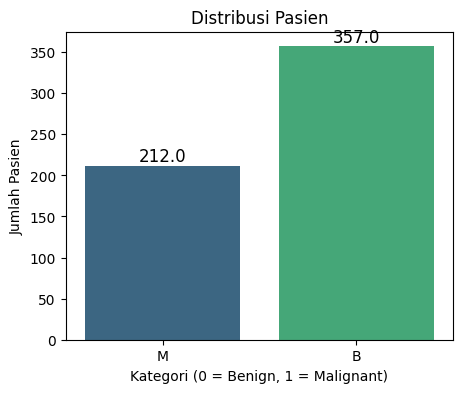

In [ ]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x='Diagnosis', data=df, palette='viridis')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height()}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=12, color='black')

plt.xlabel("Kategori (0 = Benign, 1 = Malignant)")
plt.ylabel("Jumlah Pasien")
plt.title("Distribusi Pasien")
plt.show()

### distribusi target variable

In [ ]:
# Distribusi target variable
df['Diagnosis'].value_counts(normalize=True)

,proportion
Diagnosis,
B,0.627417
M,0.372583


### visualisasi distribusi

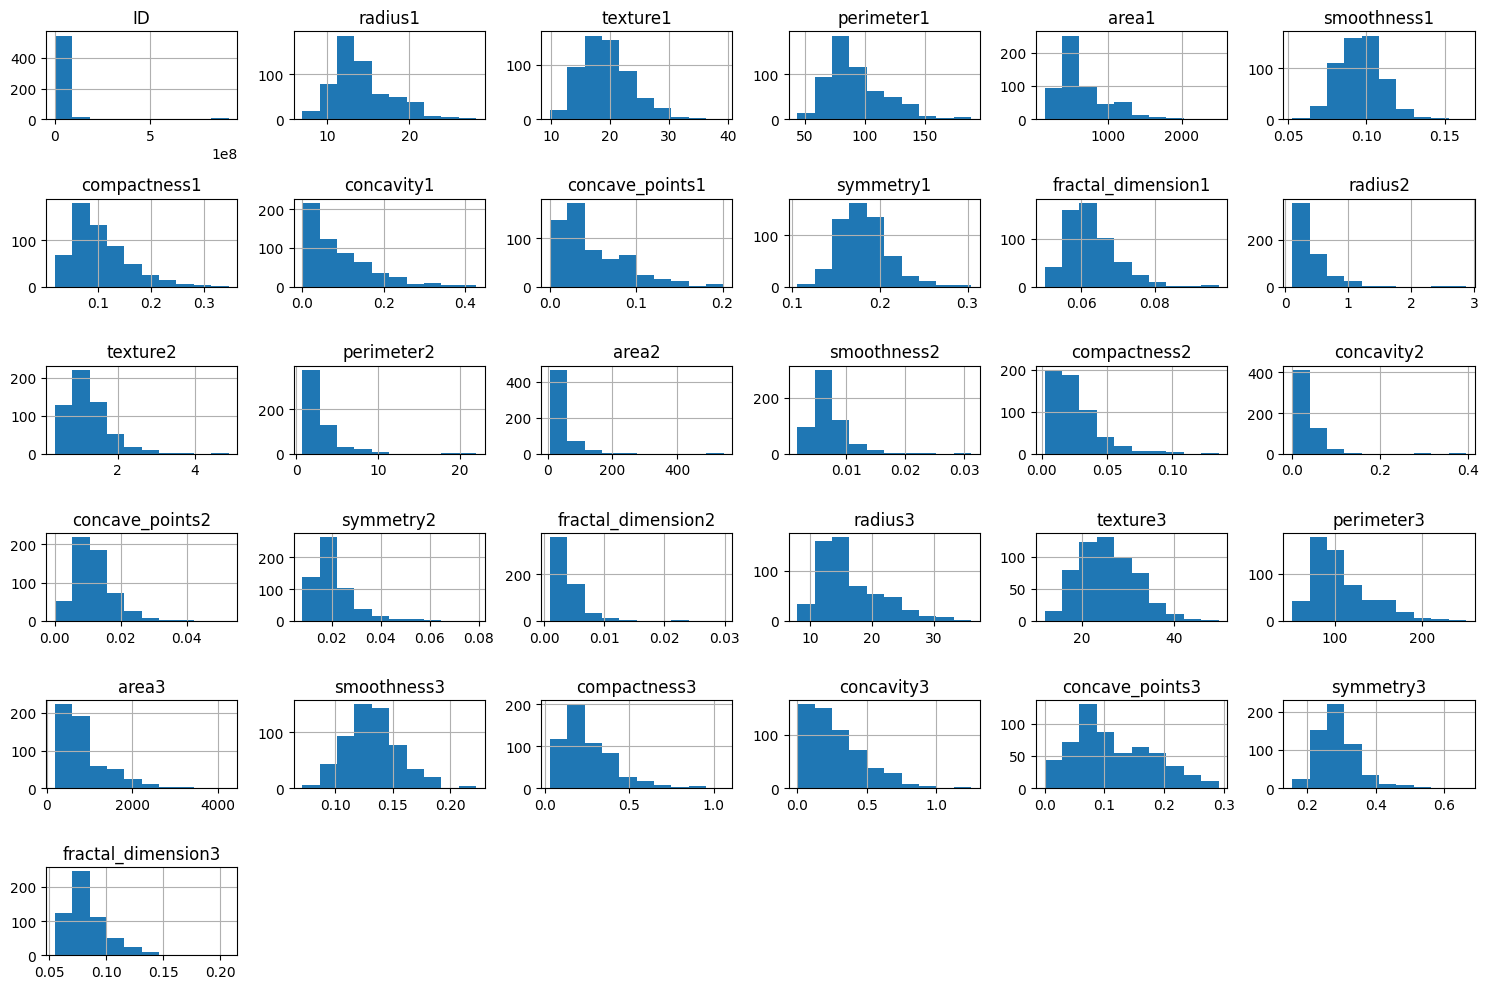

In [ ]:
# Histogram untuk variabel numerik
numeric_features = df.select_dtypes(include=[np.number]).columns
df[numeric_features].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

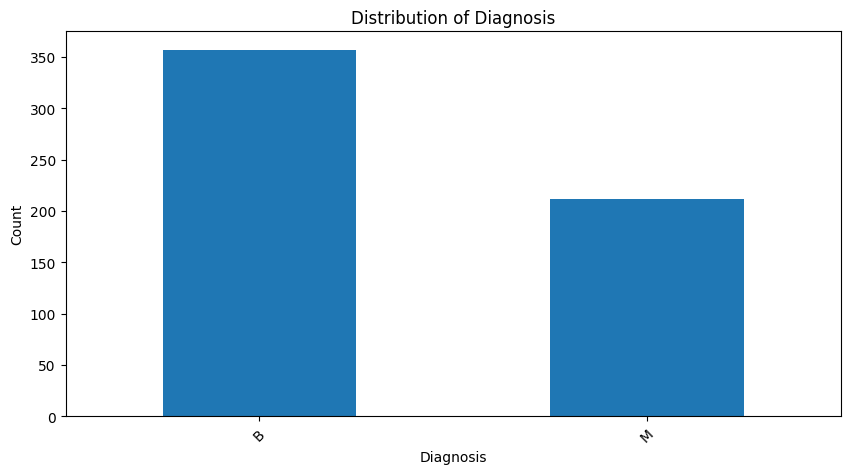

In [ ]:
# Bar plot untuk variabel kategorikal
categorical_features = df.select_dtypes(include=['object']).columns
for feature in categorical_features:
    plt.figure(figsize=(10, 5))
    df[feature].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {feature}')
    plt.ylabel('Count')
    plt.xlabel(feature)
    plt.xticks(rotation=45)
    plt.show()

### analisis korelasi

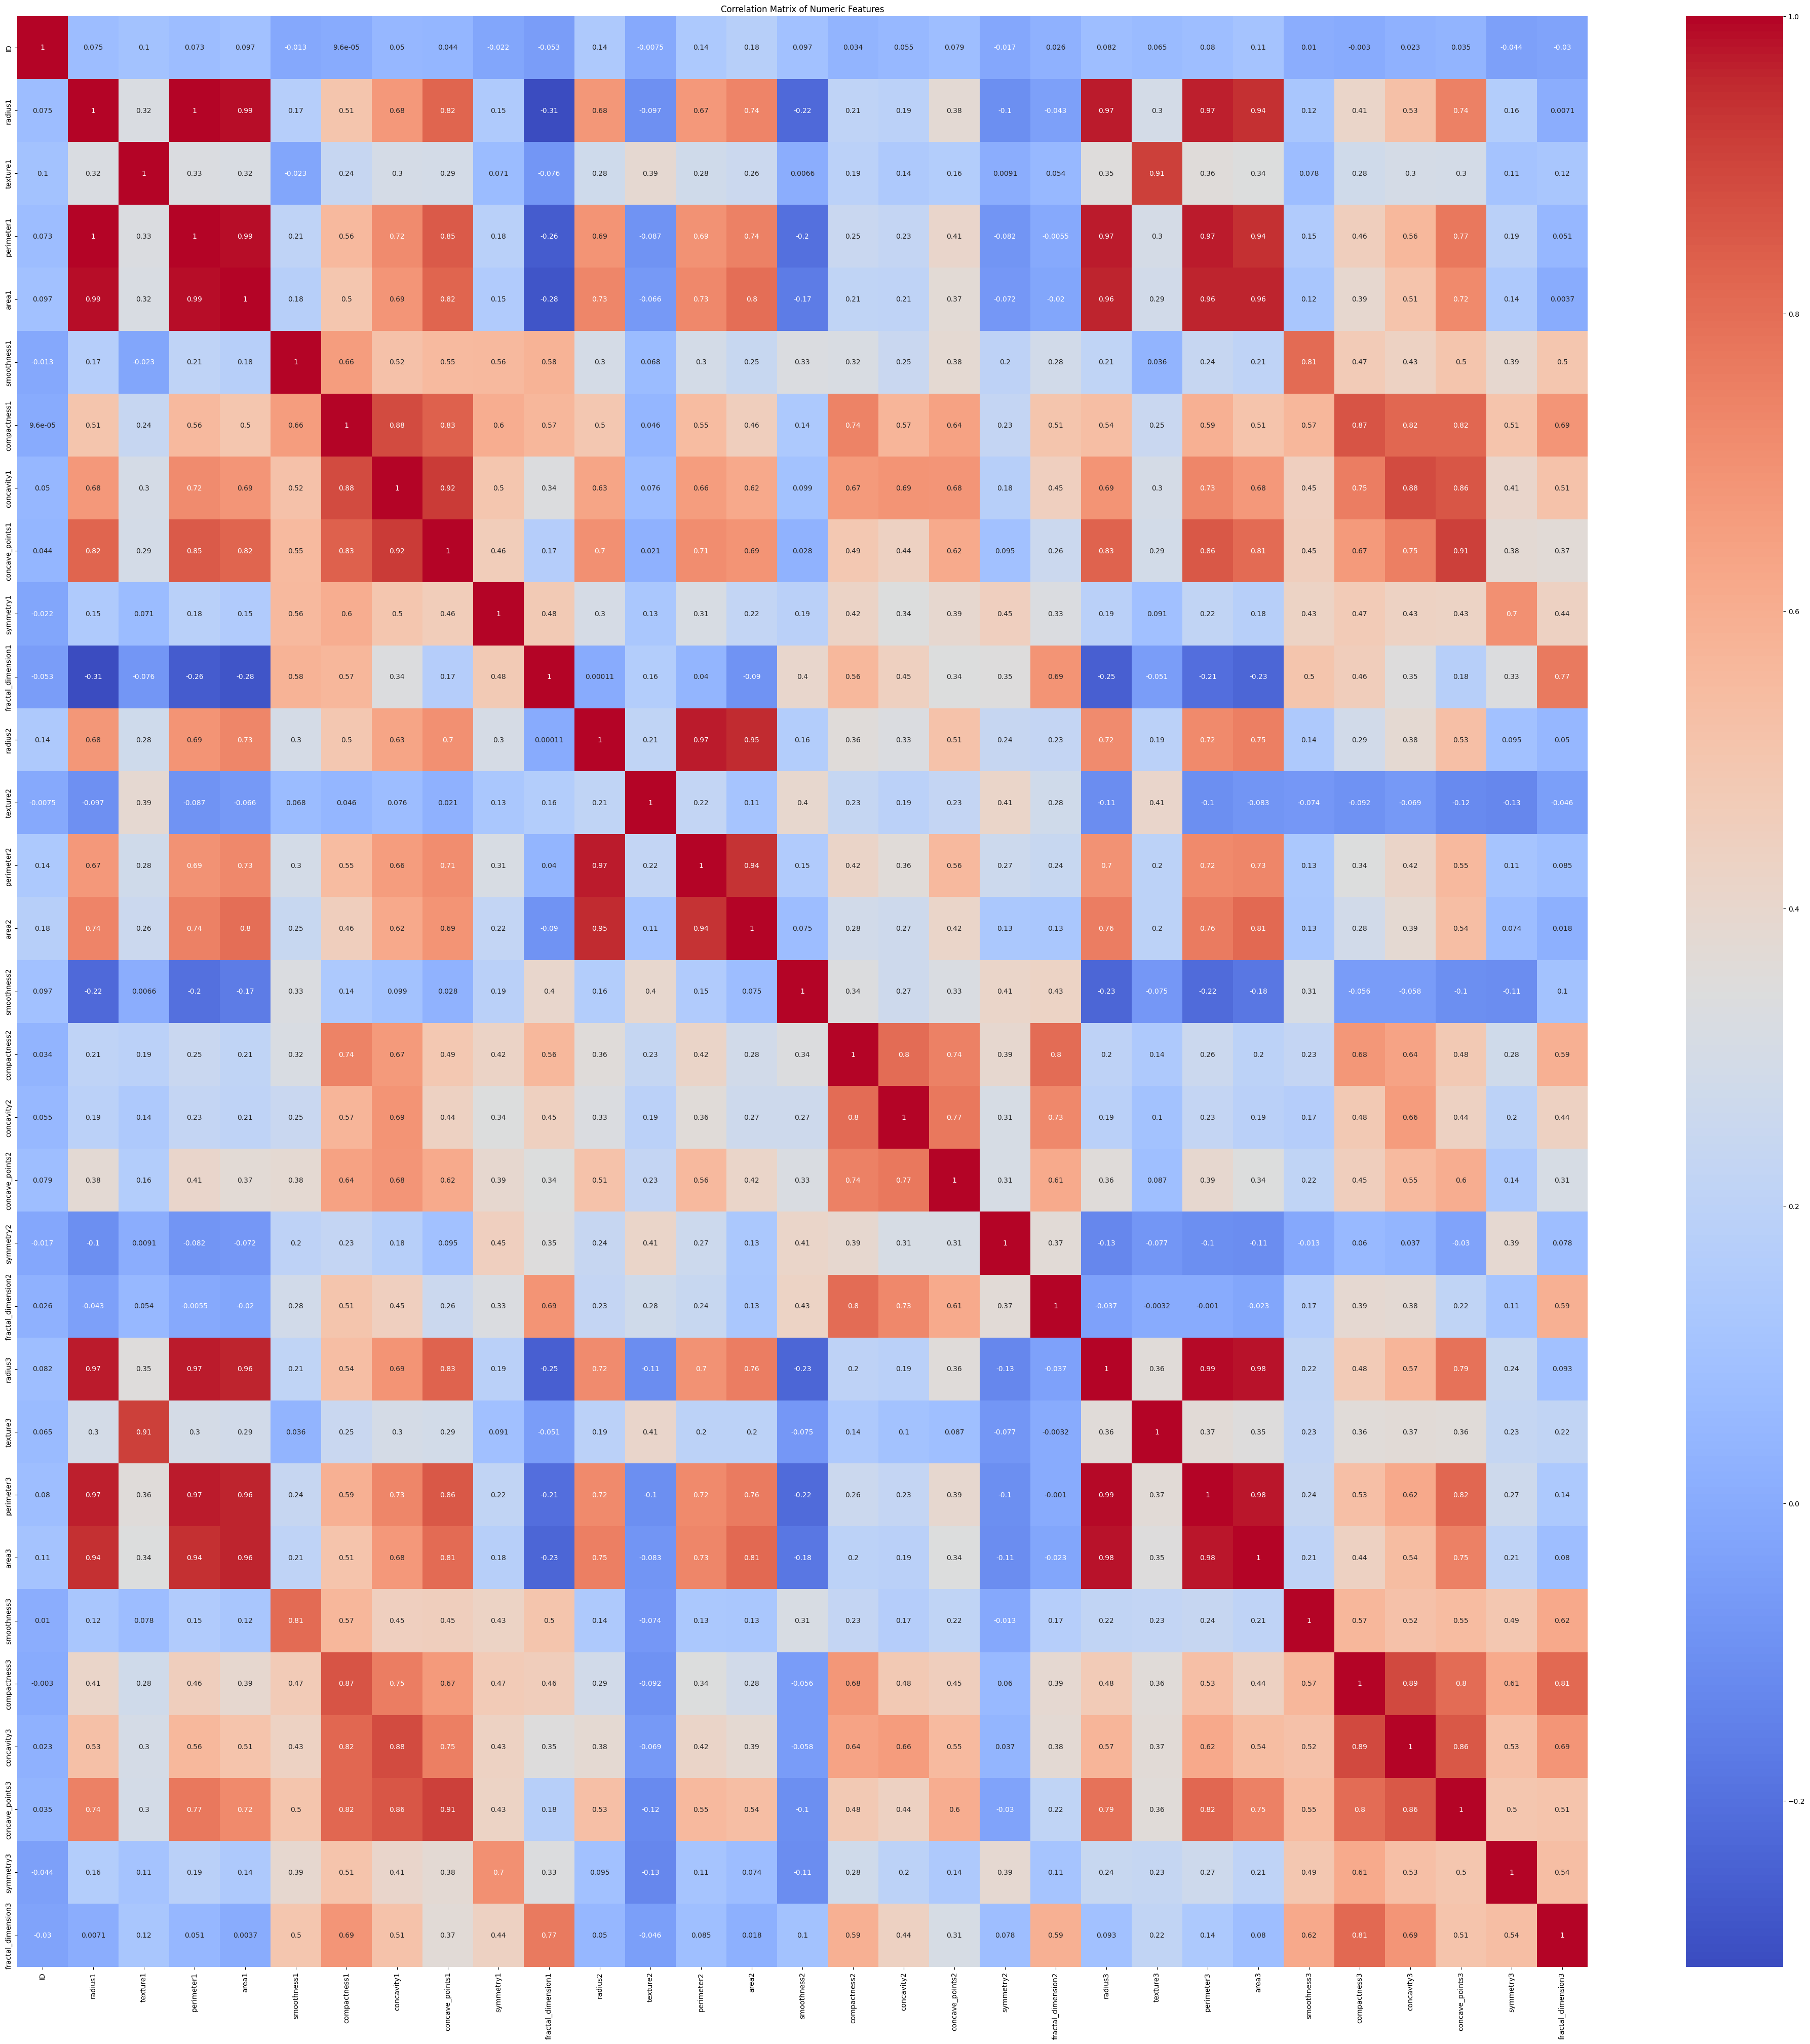

In [ ]:
# Korelasi antara variabel numerik
correlation_matrix = df[numeric_features].corr()
plt.figure(figsize=(50, 50))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### identifikasi outlier

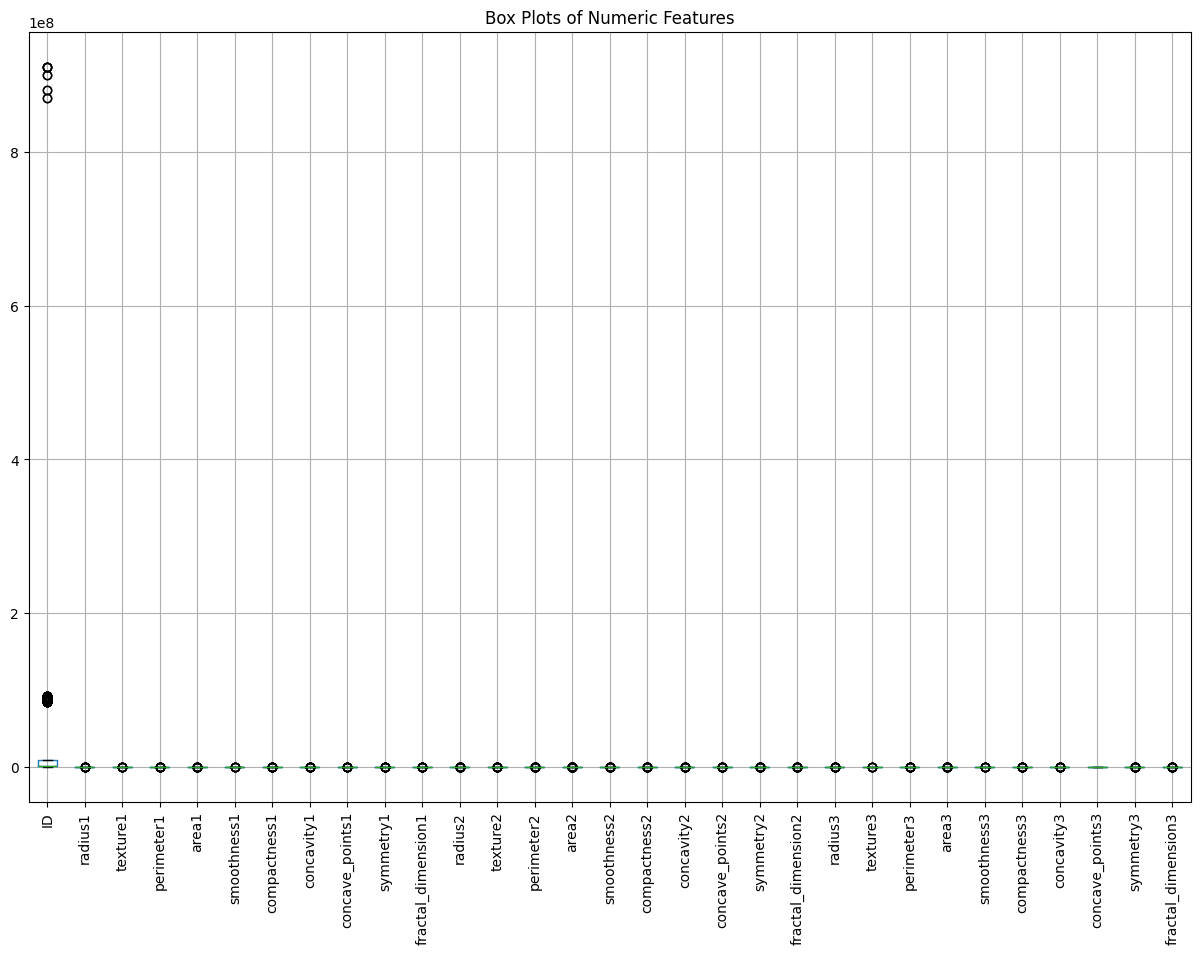

In [ ]:
# Box plot untuk mendeteksi outlier pada variabel numerik
plt.figure(figsize=(15, 10))
df[numeric_features].boxplot()
plt.title('Box Plots of Numeric Features')
plt.xticks(rotation=90)
plt.show()

In [ ]:
df_numeric = df.select_dtypes(include=['number'])
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df_numeric < (Q1 - 1.5 * IQR)) | (df_numeric > (Q3 + 1.5 * IQR))).sum()
outliers_sorted = outliers.sort_values(ascending=False)
print("\nJumlah Outlier Berdasarkan IQR:\n", outliers_sorted)


Jumlah Outlier Berdasarkan IQR:
 ID                    81
area2                 65
radius2               38
perimeter2            38
area3                 35
smoothness2           30
fractal_dimension2    28
compactness2          28
symmetry2             27
area1                 25
fractal_dimension3    24
symmetry3             23
concavity2            22
texture2              20
concave_points2       19
concavity1            18
radius3               17
compactness3          16
compactness1          16
symmetry1             15
fractal_dimension1    15
perimeter3            15
radius1               14
perimeter1            13
concavity3            12
concave_points1       10
texture1               7
smoothness3            7
smoothness1            6
texture3               5
concave_points3        0
dtype: int64


## **3**. Membersihkan Data


### menangani missing values

In [ ]:
# Cek missing values
print("Missing values sebelum pembersihan:")
print(df.isnull().sum())

# Menangani missing values
for column in df.columns:
    if df[column].dtype == 'object':
        # Untuk kolom kategorikal, isi dengan modus
        df[column].fillna(df[column].mode()[0], inplace=True)
    else:
        # Untuk kolom numerik, isi dengan median
        df[column].fillna(df[column].median(), inplace=True)

print("\nMissing values setelah pembersihan:")
print(df.isnull().sum())

Missing values sebelum pembersihan:
ID                    0
Diagnosis             0
radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
dtype: int64

Missing values setelah pembersihan:
ID                    0
Diagnosis             0
radius1               0
texture1              0
perimeter1            0
area1                 0
sm

/tmp/ipython-input-1654905950.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].median(), inplace=True)
/tmp/ipython-input-1654905950.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

### menangani duplikat

In [ ]:
# Cek duplikat
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicate_count}")

# Hapus duplikat
df.drop_duplicates(inplace=True)

print(f"Jumlah baris setelah menghapus duplikat: {len(df)}")

Jumlah baris duplikat: 0
Jumlah baris setelah menghapus duplikat: 569


## 4. Mengkonstruksi Data

### transformasi data

In [ ]:
# Periksa kategori unik untuk kolom kategorikal
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f"\nKategori unik dalam {col}:")
    print(df[col].unique())


Kategori unik dalam Diagnosis:
['M' 'B']


In [ ]:
le = LabelEncoder()
df['Diagnosis'] = le.fit_transform(df['Diagnosis'])

In [ ]:
df.head()

,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# drop ID karena tidak berpengaruh pada klasifikasi
# Check if 'ID' column exists before dropping
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)
else:
    print("Column 'ID' not found in DataFrame.")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Diagnosis           569 non-null    int64  
 1   radius1             569 non-null    float64
 2   texture1            569 non-null    float64
 3   perimeter1          569 non-null    float64
 4   area1               569 non-null    float64
 5   smoothness1         569 non-null    float64
 6   compactness1        569 non-null    float64
 7   concavity1          569 non-null    float64
 8   concave_points1     569 non-null    float64
 9   symmetry1           569 non-null    float64
 10  fractal_dimension1  569 non-null    float64
 11  radius2             569 non-null    float64
 12  texture2            569 non-null    float64
 13  perimeter2          569 non-null    float64
 14  area2               569 non-null    float64
 15  smoothness2         569 non-null    float64
 16  compactn

### cek kembali korelasi


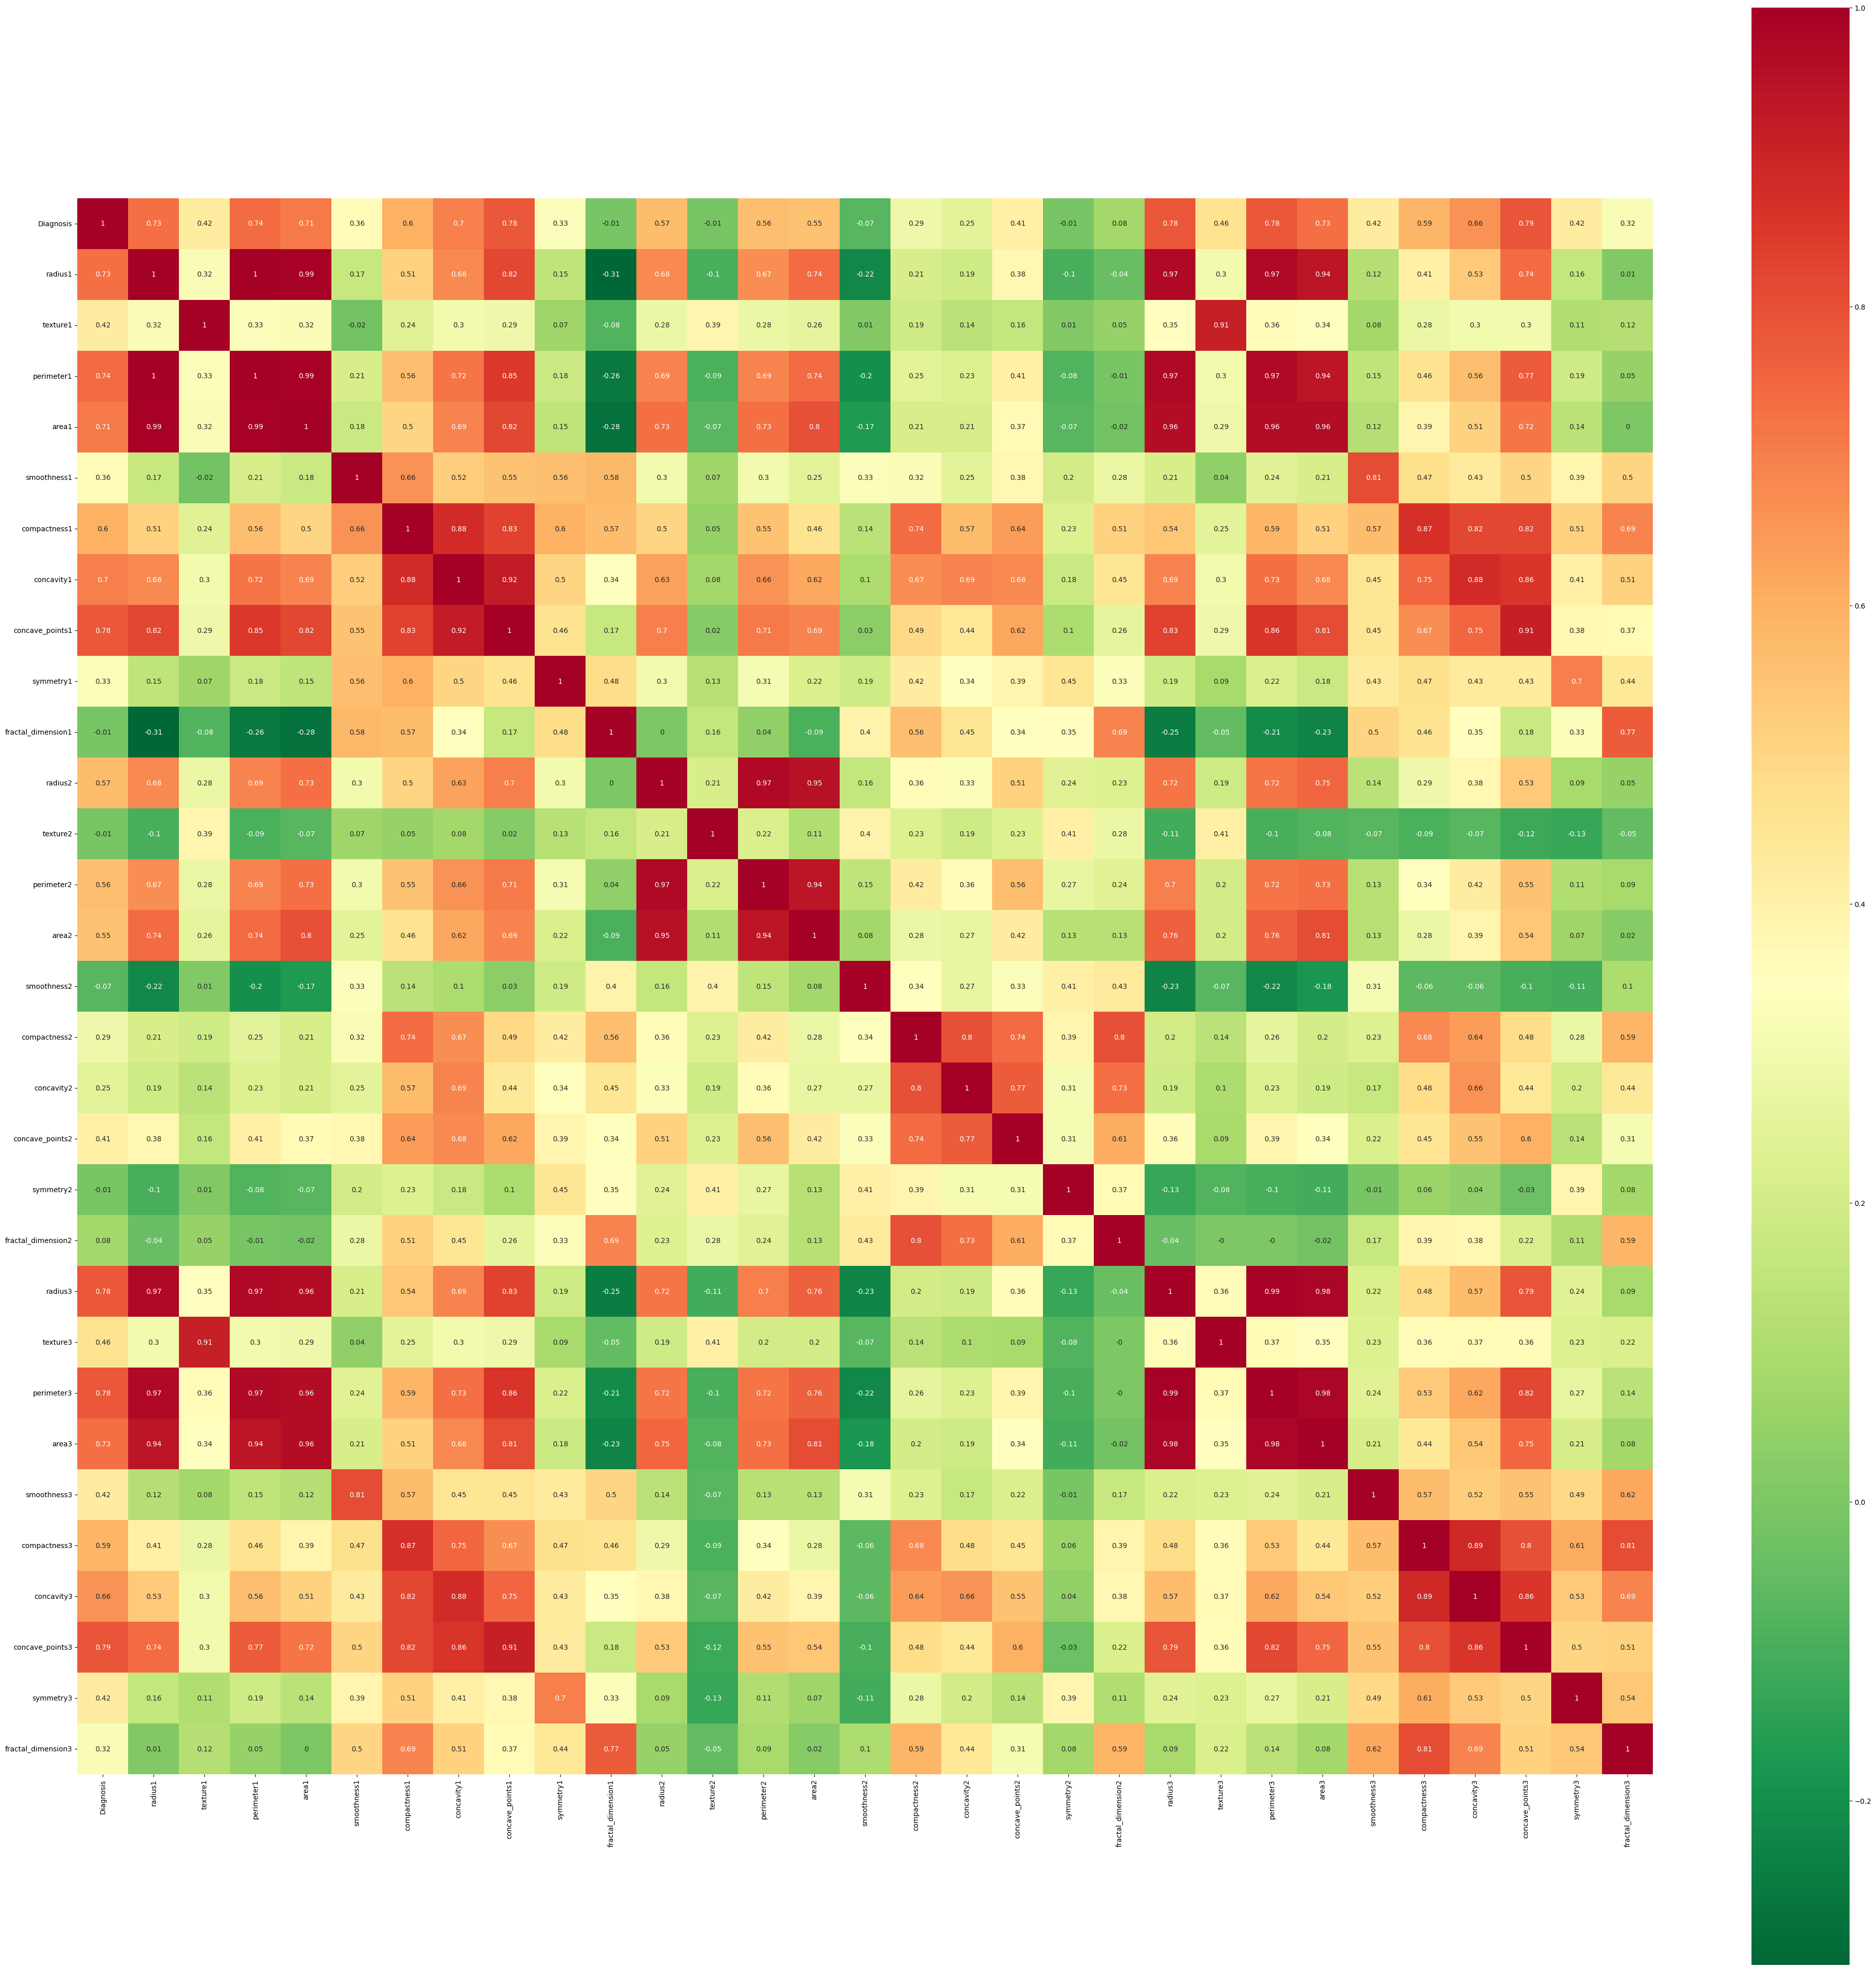

In [ ]:
# Correlation Heatmap
correlation = df.corr()
plt.subplots(figsize = (50,50))
sns.heatmap(correlation.round(2),
            annot = True,
            vmax = 1,
            square = True,
            cmap = 'RdYlGn_r')
plt.show()

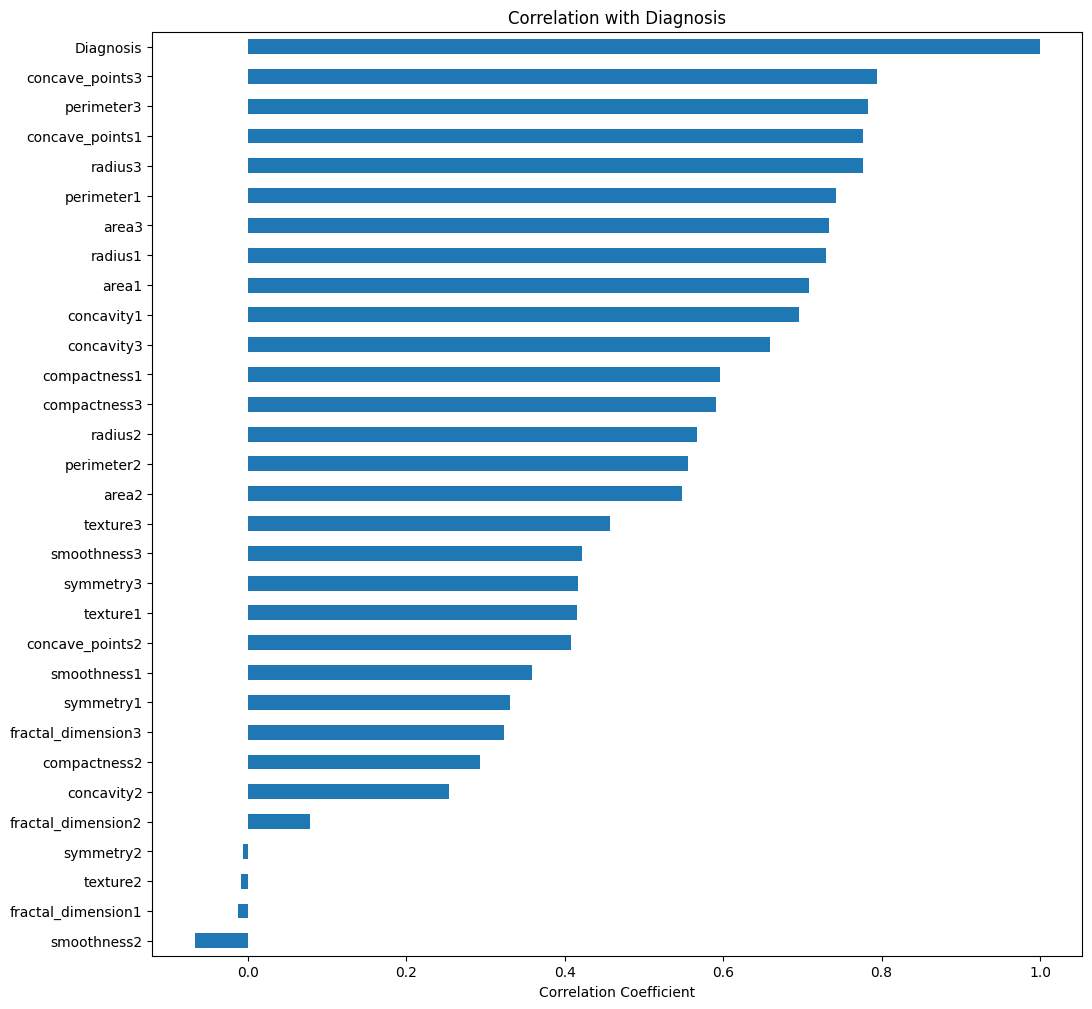

In [ ]:
plt.figure(figsize=(12, 12))
corr = df.corr()['Diagnosis'].sort_values(ascending=True)
corr.plot(kind='barh')
plt.title('Correlation with Diagnosis')
plt.xlabel('Correlation Coefficient')
plt.show()

### feature selection dengan chi2

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2

In [ ]:
# Pisahkan fitur dan target DARI DF ASLI
X_original = df.drop('Diagnosis', axis=1)
y_original = df['Diagnosis']

In [ ]:
# Split Test-Train (10% test)
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_original, y_original, test_size=0.1, random_state=42, stratify=y_original
)

In [ ]:
# Scaling fitur HANYA UNTUK perhitungan skor Chi2
scaler_chi2 = MinMaxScaler()
X_train_chi2_scaled = scaler_chi2.fit_transform(X_train_full)

In [ ]:
# Hitung skor untuk SEMUA fitur
selector_chi2 = SelectKBest(score_func=chi2, k='all')
selector_chi2.fit(X_train_chi2_scaled, y_train_full)

SelectKBest(k='all', score_func=<function chi2 at 0x7baaf210a7a0>)

In [ ]:
# Buat DataFrame skor dan urutkan
chi2_scores_df = pd.DataFrame({
    'Fitur': X_train_full.columns,
    'Skor_Chi2': selector_chi2.scores_
}).sort_values(by='Skor_Chi2', ascending=False).reset_index(drop=True)

print("Peringkat Fitur Berdasarkan Chi-Square:")
print(chi2_scores_df.to_string())

Peringkat Fitur Berdasarkan Chi-Square:
                 Fitur  Skor_Chi2
0      concave_points1  47.704702
1           concavity1  41.841923
2      concave_points3  41.577207
3                area3  31.843266
4           perimeter3  31.299567
5              radius3  30.855405
6           concavity3  27.789702
7                area1  26.475035
8           perimeter1  23.856547
9              radius1  22.323021
10        compactness1  19.186956
11        compactness3  18.876998
12               area2  18.430961
13             radius2  16.423247
14          perimeter2  15.406083
15            texture3   8.061342
16        compactness2   6.100187
17            texture1   5.895706
18     concave_points2   5.466587
19         smoothness3   5.394156
20           symmetry3   4.911462
21  fractal_dimension3   4.200376
22         smoothness1   4.002087
23           symmetry1   2.695648
24          concavity2   2.363480
25  fractal_dimension2   0.355056
26         smoothness2   0.068104
27      

In [ ]:
percentage_to_keep = 0.75

In [ ]:
total_features = len(X_train_full.columns)
k_features = int(total_features * percentage_to_keep)
print(f"\n\n--- Menjalankan Eksperimen Chi-Square dengan {k_features}/{total_features} Fitur ({percentage_to_keep*100:.0f}%) ---")



--- Menjalankan Eksperimen Chi-Square dengan 22/30 Fitur (75%) ---


In [ ]:
# Ambil nama-nama fitur teratas
top_k_feature_names = chi2_scores_df['Fitur'].head(k_features).tolist()

print("\nFitur dan skor yang digunakan dalam eksperimen ini:")
print(chi2_scores_df.head(k_features).to_string())


Fitur dan skor yang digunakan dalam eksperimen ini:
                 Fitur  Skor_Chi2
0      concave_points1  47.704702
1           concavity1  41.841923
2      concave_points3  41.577207
3                area3  31.843266
4           perimeter3  31.299567
5              radius3  30.855405
6           concavity3  27.789702
7                area1  26.475035
8           perimeter1  23.856547
9              radius1  22.323021
10        compactness1  19.186956
11        compactness3  18.876998
12               area2  18.430961
13             radius2  16.423247
14          perimeter2  15.406083
15            texture3   8.061342
16        compactness2   6.100187
17            texture1   5.895706
18     concave_points2   5.466587
19         smoothness3   5.394156
20           symmetry3   4.911462
21  fractal_dimension3   4.200376


In [ ]:
# Buat subset data training dan test dengan fitur terpilih
X_train_selected = X_train_full[top_k_feature_names]
X_test_selected = X_test_full[top_k_feature_names]

## 4. Membangun Model


In [ ]:
print("\n--- Memulai Optimisasi Hiperparameter dengan Optuna ---")

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

X_train_np = X_train_selected.values
y_train_np = y_train_full.values


--- Memulai Optimisasi Hiperparameter dengan Optuna ---


### membangun dengan TabNet (Optimization)

In [ ]:
def objective(trial):
    params = {
        'n_d': trial.suggest_int('n_d', 8, 64), 'n_a': trial.suggest_int('n_a', 8, 64),
        'n_steps': trial.suggest_int('n_steps', 3, 6), 'gamma': trial.suggest_float('gamma', 1.0, 1.5),
        'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-5, 1e-3, log=True)
    }
    fit_params = {
        'batch_size': trial.suggest_int('batch_size', 32, 128),
        'virtual_batch_size': trial.suggest_int('virtual_batch_size', 16, 64)
    }
    optimizer_params = {
        'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'betas': (trial.suggest_float('beta1', 0.85, 0.99), trial.suggest_float('beta2', 0.99, 0.9999))
    }

    cv_scores = []
    for train_idx, val_idx in skf.split(X_train_np, y_train_np):
        X_tr_fold, X_val_fold = X_train_np[train_idx], X_train_np[val_idx]
        y_tr_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]

        scaler = StandardScaler()
        X_tr_fold_scaled = scaler.fit_transform(X_tr_fold)
        X_val_fold_scaled = scaler.transform(X_val_fold)

        smote_enn = SMOTEENN(random_state=42)
        X_tr_fold_resampled, y_tr_fold_resampled = smote_enn.fit_resample(X_tr_fold_scaled, y_tr_fold)

        model = TabNetClassifier(
            **params,
            optimizer_fn=torch.optim.Adam,
            optimizer_params=optimizer_params,
            verbose=0,
            seed=42
        )

        model.fit(
            X_train=X_tr_fold_resampled, y_train=y_tr_fold_resampled,
            eval_set=[(X_val_fold_scaled, y_val_fold)],
            max_epochs=100,
            patience=10,
            **fit_params
        )

        y_pred_val = model.predict(X_val_fold_scaled)
        cv_scores.append(accuracy_score(y_val_fold, y_pred _val))

    return np.mean(cv_scores)

In [ ]:
# Hyperparameter Tuning
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2026-02-06 04:41:53,894] A new study created in memory with name: no-name-db3c2d48-8d1a-413c-957e-0236c62ea3f7



Early stopping occurred at epoch 35 with best_epoch = 25 and best_val_0_auc = 1.0


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 56 with best_epoch = 46 and best_val_0_auc = 0.98543


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


...


Early stopping occurred at epoch 21 with best_epoch = 11 and best_val_0_auc = 0.99753


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 28 with best_epoch = 18 and best_val_0_auc = 0.99507


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-02-06 05:07:33,907] Trial 29 finished with value: 0.9667428136303066 and parameters: {'n_d': 58, 'n_a': 37, 'n_steps': 3, 'gamma': 1.1184174167073493, 'lambda_sparse': 0.0003265318453206207, 'batch_size': 33, 'virtual_batch_size': 38, 'lr': 0.007905876324999565, 'beta1': 0.9205480369348927, 'beta2': 0.9974883965740975}. Best is trial 21 with value: 0.9668379973348562.



Early stopping occurred at epoch 22 with best_epoch = 12 and best_val_0_auc = 0.98972


In [ ]:
# Tampilkan hasil terbaik dari proses tuning
print("\n--- Hasil Optimisasi ---")
print(f"Akurasi validasi terbaik (rata-rata CV): {study.best_value:.4f}")
print("Hiperparameter terbaik ditemukan:")
print(study.best_params)


--- Hasil Optimisasi ---
Akurasi validasi terbaik (rata-rata CV): 0.9668
Hiperparameter terbaik ditemukan:
{'n_d': 49, 'n_a': 61, 'n_steps': 3, 'gamma': 1.024588445100507, 'lambda_sparse': 0.0005339659303013343, 'batch_size': 44, 'virtual_batch_size': 31, 'lr': 0.009614498677467826, 'beta1': 0.9241822496858302, 'beta2': 0.9965689703402479}


In [ ]:
print("\n--- Melatih Model Final dengan Hiperparameter Terbaik ---")

best_params = study.best_params

# Pra-pemrosesan pada SELURUH data training
final_scaler = StandardScaler()
X_train_final_scaled = final_scaler.fit_transform(X_train_selected)

final_smote_enn = SMOTEENN(random_state=42)
X_train_final_resampled, y_train_final_resampled = final_smote_enn.fit_resample(X_train_final_scaled, y_train_full)


--- Melatih Model Final dengan Hiperparameter Terbaik ---


In [ ]:
# Siapkan parameter untuk model final dari hasil Optuna
final_model_params = {
    'n_d': best_params['n_d'], 'n_a': best_params['n_a'],
    'n_steps': best_params['n_steps'], 'gamma': best_params['gamma'],
    'lambda_sparse': best_params['lambda_sparse'],
    'optimizer_fn': torch.optim.Adam,
    'optimizer_params': {
        'lr': best_params['lr'],
        'betas': (best_params['beta1'], best_params['beta2'])
    },
    'verbose': 1,
    'seed': 42
}
final_fit_params = {
    'batch_size': best_params['batch_size'],
    'virtual_batch_size': best_params['virtual_batch_size']
}

In [ ]:
# Buat instance model final
final_model_optimized = TabNetClassifier(**final_model_params)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [ ]:
# Ukur waktu komputasi untuk pelatihan
start_time = time.time()

In [ ]:
# PERBAIKAN: Latih model final pada seluruh data training
final_model_optimized.fit(
    X_train=X_train_final_resampled, y_train=y_train_final_resampled,
    max_epochs=100,
    patience=10,
    **final_fit_params
)

end_time = time.time()
training_time = end_time - start_time
print(f"Waktu Pelatihan Model Final: {training_time:.2f} detik")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 0.89774 |  0:00:00s
epoch 1  | loss: 0.20314 |  0:00:00s
epoch 2  | loss: 0.13633 |  0:00:00s
epoch 3  | loss: 0.12567 |  0:00:01s
epoch 4  | loss: 0.10464 |  0:00:01s
epoch 5  | loss: 0.07652 |  0:00:01s
epoch 6  | loss: 0.09024 |  0:00:02s
epoch 7  | loss: 0.05208 |  0:00:02s
epoch 8  | loss: 0.14701 |  0:00:02s
epoch 9  | loss: 0.11708 |  0:00:03s
epoch 10 | loss: 0.08477 |  0:00:03s
epoch 11 | loss: 0.07617 |  0:00:04s
epoch 12 | loss: 0.07152 |  0:00:04s
epoch 13 | loss: 0.08653 |  0:00:04s
epoch 14 | loss: 0.0539  |  0:00:05s
epoch 15 | loss: 0.04327 |  0:00:05s
epoch 16 | loss: 0.0776  |  0:00:05s
epoch 17 | loss: 0.07564 |  0:00:05s
epoch 18 | loss: 0.07571 |  0:00:06s
epoch 19 | loss: 0.08964 |  0:00:06s
epoch 20 | loss: 0.05726 |  0:00:06s
epoch 21 | loss: 0.05077 |  0:00:06s
epoch 22 | loss: 0.07967 |  0:00:07s
epoch 23 | loss: 0.0671  |  0:00:07s
epoch 24 | loss: 0.04577 |  0:00:07s
epoch 25 | loss: 0.03538 |  0:00:08s
epoch 26 | loss: 0.02912 |  0:00:08s
e

In [ ]:
# Pra-pemrosesan pada data test (HANYA transform)
X_test_final_scaled = final_scaler.transform(X_test_selected)

In [ ]:
# 1. Minta model menjelaskan hasil pada data uji yang sudah di-scale
# Pastikan X_test_final_scaled adalah data test yang sudah melewati StandardScaler
explain_matrix, masks = final_model_optimized.explain(X_test_final_scaled)

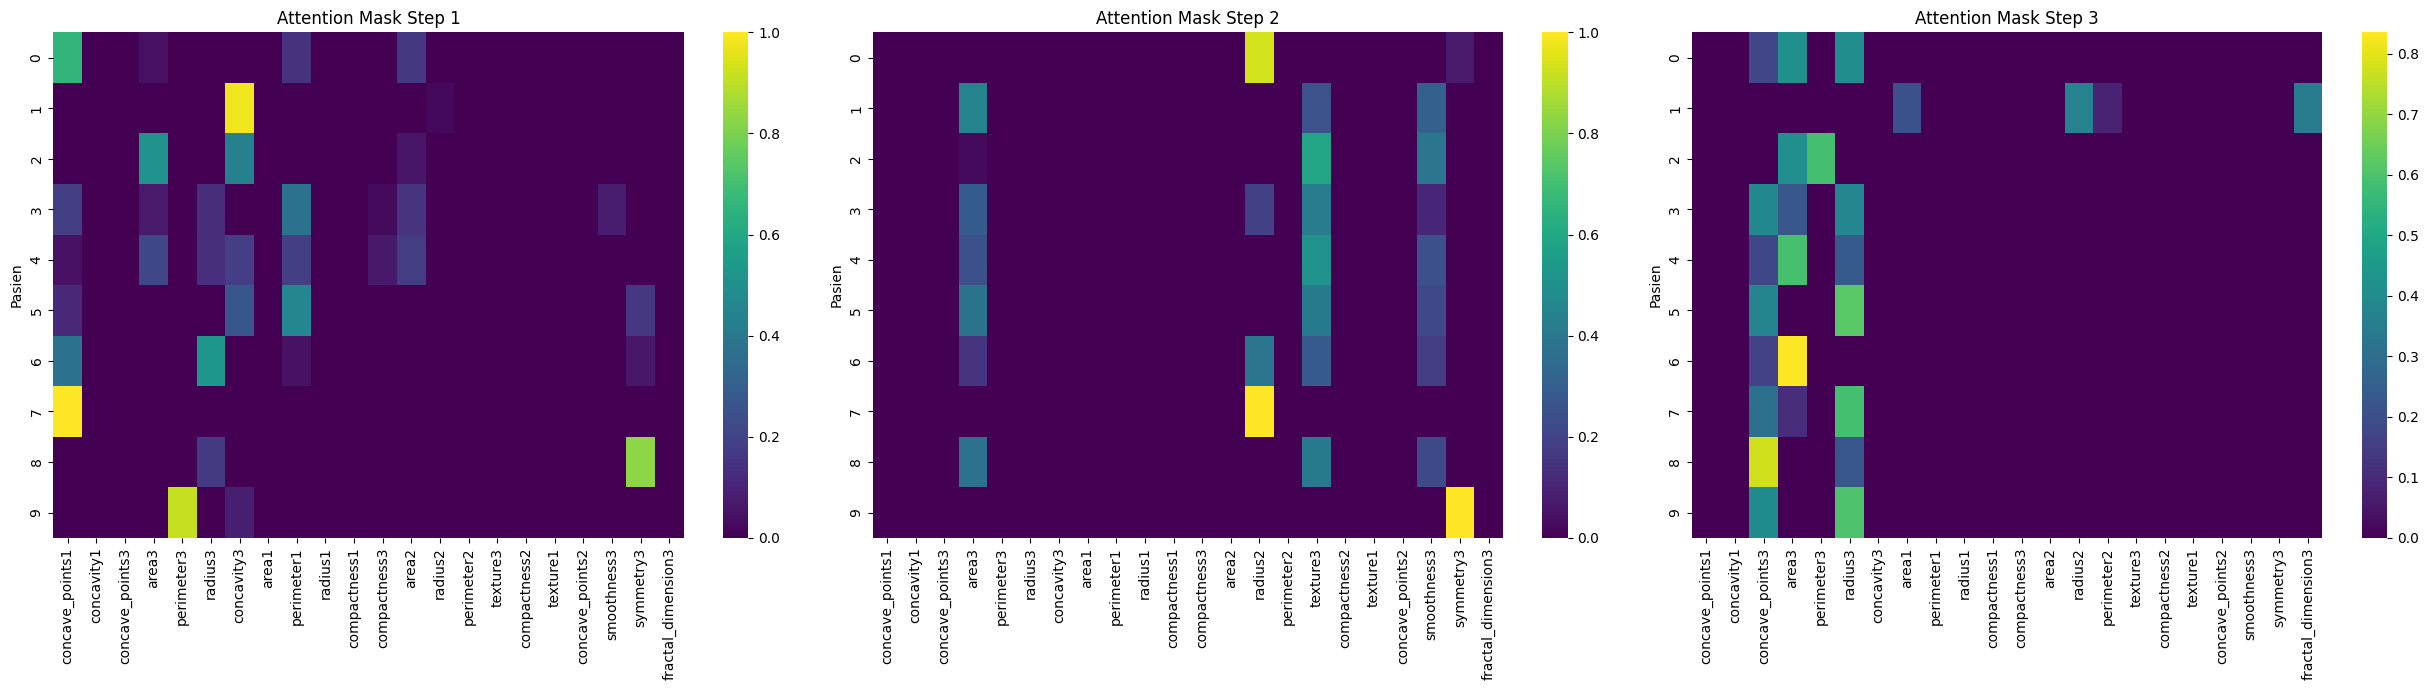

In [ ]:
# 2. Visualisasi Heatmap Attention Masks (10 Pasien Pertama)
feature_names_list = top_k_feature_names

n_patients = 10
n_steps = len(masks)
fig, axs = plt.subplots(1, n_steps, figsize=(25, 7))

for i in range(n_steps):
    mask_data = masks[i][:n_patients]
    sns.heatmap(mask_data, ax=axs[i], cmap='viridis', cbar=True,
                xticklabels=feature_names_list)
    axs[i].set_title(f"Attention Mask Step {i+1}")
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=90)
    axs[i].set_ylabel("Pasien")

plt.tight_layout()
plt.show()

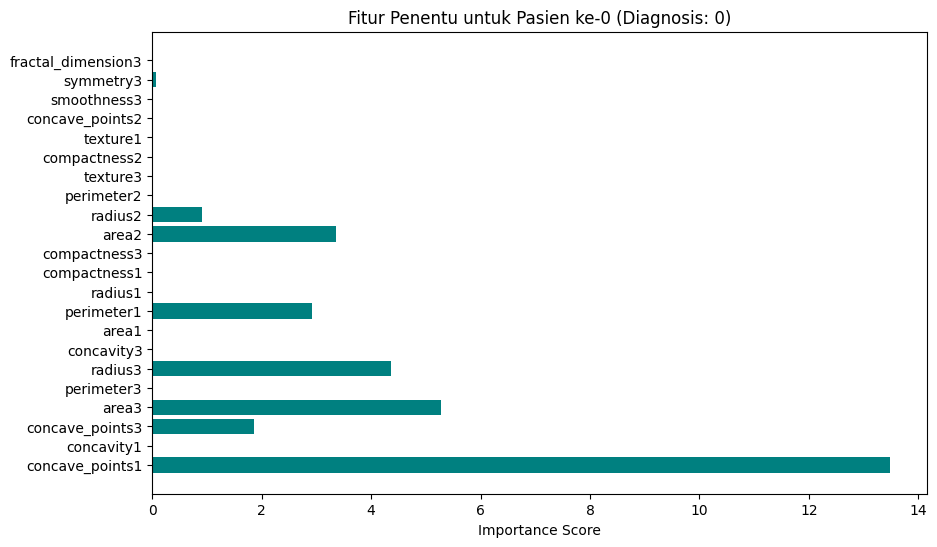

In [ ]:
# 3. Visualisasi Lokal untuk SATU PASIEN (Contoh: Pasien indeks 0)
patient_idx = 0
patient_importance = explain_matrix[patient_idx]

# Ambil nama fitur dari DataFrame asli agar grafiknya ada namanya, bukan angka
# (Asumsi X_train adalah DataFrame sebelum dikonversi ke NumPy)
feature_names = X_train_selected.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, patient_importance, color='teal')
plt.title(f"Fitur Penentu untuk Pasien ke-0 (Diagnosis: {y_test_full.iloc[patient_idx]})")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
# Evaluasi pada Test Set
print("\n--- Evaluasi Final pada Test Set (Dengan Optimasi, Dengan FS) ---")
y_pred_test = final_model_optimized.predict(X_test_final_scaled)


--- Evaluasi Final pada Test Set (Dengan Optimasi, Dengan FS) ---


In [ ]:
# Tampilkan semua metrik yang relevan
accuracy = accuracy_score(y_test_full, y_pred_test)
recall = recall_score(y_test_full, y_pred_test)
precision = precision_score(y_test_full, y_pred_test)
f1 = f1_score(y_test_full, y_pred_test)

print(classification_report(y_test_full, y_pred_test))
print(f"\n--- Ringkasan untuk Tabel Eksperimen ---")
print(f"Akurasi: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Presisi: {precision:.4f}")
print(f"Waktu Komputasi (Pelatihan): {training_time:.4f} detik")

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       1.00      0.95      0.98        21

    accuracy                           0.98        57
   macro avg       0.99      0.98      0.98        57
weighted avg       0.98      0.98      0.98        57


--- Ringkasan untuk Tabel Eksperimen ---
Akurasi: 0.9825
Recall: 0.9524
Presisi: 1.0000
Waktu Komputasi (Pelatihan): 24.7730 detik


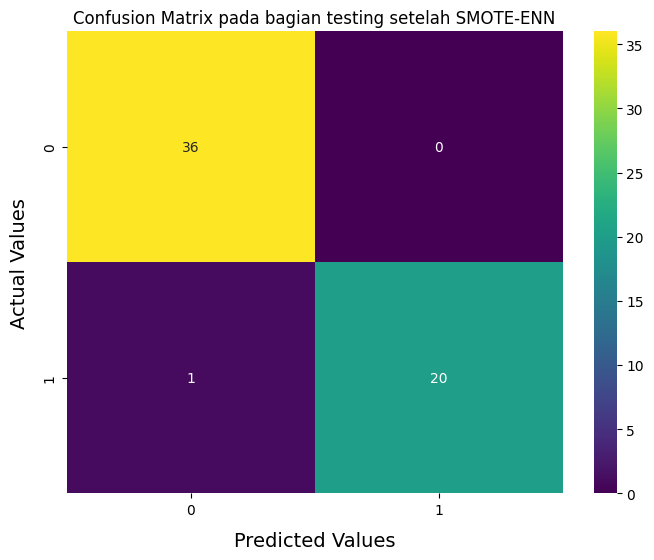

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test_full, y_pred_test),
            annot=True, cmap='viridis', fmt='.0f')
plt.xlabel('Predicted Values', fontdict={'size':14}, labelpad=10)
plt.ylabel('Actual Values', fontdict={'size':14}, labelpad=10)
plt.title('Confusion Matrix pada bagian testing setelah SMOTE-ENN')
plt.show()

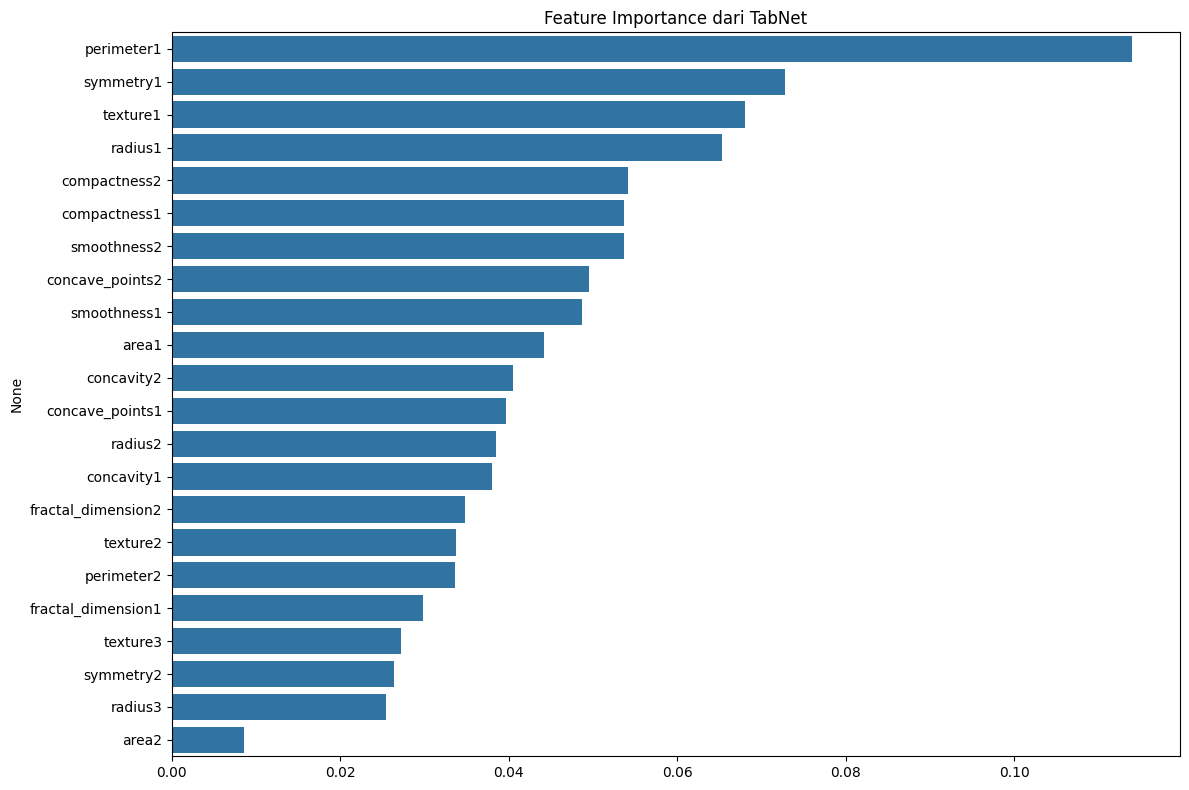

In [ ]:
# Feature importance dari model final IG
importances_ig = final_model_optimized.feature_importances_
feature_names_ig = X_train_full.columns
sorted_idx_ig = np.argsort(importances_ig)[::-1]

plt.figure(figsize=(12, 8))
sns.barplot(x=importances_ig[sorted_idx_ig], y=feature_names_ig[sorted_idx_ig])
plt.title("Feature Importance dari TabNet")
plt.tight_layout()
plt.show()

### checking dengan data training

In [ ]:
# ====================== EVALUATION METRICS ======================
from sklearn.metrics import precision_score, recall_score

# Training set evaluation
train_pred = final_model_optimized.predict(X_train_final_scaled)
train_accuracy = accuracy_score(y_train_full, train_pred) # Use y_train_values
train_precision = precision_score(y_train_full, train_pred, average='binary') # Use y_train_values
train_recall = recall_score(y_train_full, train_pred, average='binary') # Use y_train_values

print('\n=== Training Set Evaluation ===')
print(f'Akurasi pada training set: {train_accuracy:.4f}')
print(f'Precision pada training set: {train_precision:.4f}')
print(f'Recall pada training set: {train_recall:.4f}')

# Test set evaluation
test_pred = final_model_optimized.predict(X_test_final_scaled)
test_accuracy = accuracy_score(y_test_full, test_pred)
test_precision = precision_score(y_test_full, test_pred, average='binary')
test_recall = recall_score(y_test_full, test_pred, average='binary')

print('\n=== Test Set Evaluation ===')
print(f'Akurasi pada test set: {test_accuracy:.4f}')
print(f'Precision pada test set: {test_precision:.4f}')
print(f'Recall pada test set: {test_recall:.4f}')


=== Training Set Evaluation ===
Akurasi pada training set: 0.9746
Precision pada training set: 0.9837
Recall pada training set: 0.9476

=== Test Set Evaluation ===
Akurasi pada test set: 0.9825
Precision pada test set: 1.0000
Recall pada test set: 0.9524
